## RNN Model Building LSTM (Long Short-Term Memory)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import edf

original_df, _, _, _, _ = edf.get_data_for_modeling()

d:\machinelearning project\edf.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Timestamp'] = pd.to_datetime(df['Timestamp'])


In [ ]:
# Prepare the data for LSTM model
demand_data = original_df[['Demand']].values
training_data_len = int(np.ceil(len(demand_data) * 0.8)) #

# Preprocessing: Standardize the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(demand_data)

train_data = scaled_data[0:training_data_len, :]

X_train = []
Y_train = []

# Create a sliding window of 24 hours to predict the next hour's demand
for i in range(24, len(train_data)):
    X_train.append(train_data[i-24:i, 0])
    Y_train.append(train_data[i, 0])

X_train, Y_train = np.array(X_train), np.array(Y_train)
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

In [3]:
# Building the LSTM model
model = keras.models.Sequential([
    keras.layers.LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], 1)),
    keras.layers.LSTM(64, return_sequences=False),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(1)
])

model.summary()
model.compile(optimizer='adam', loss='mae', metrics=[keras.metrics.RootMeanSquaredError()])

history = model.fit(X_train, Y_train, epochs=10, batch_size=32, validation_split=0.1)

d:\machinelearning project\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 66,561 (260.00 KB)

 Trainable params: 66,561 (260.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
983/983 ━━━━━━━━━━━━━━━━━━━━ 41s 28ms/step - loss: 0.1734 - root_mean_squared_error: 0.2504 - val_loss: 0.1456 - val_root_mean_squared_error: 0.1838
Epoch 2/10
983/983 ━━━━━━━━━━━━━━━━━━━━ 25s 26ms/step - loss: 0.1413 - root_mean_squared_error: 0.1807 - val_loss: 0.1292 - val_root_mean_squared_error: 0.1630
Epoch 3/10
983/983 ━━━━━━━━━━━━━━━━━━━━ 29s 30ms/step - loss: 0.1377 - root_mean_squared_error: 0.1759 - val_loss: 0.1337 - val_root_mean_squared_error: 0.1677
Epoch 4/10
983/983 ━━━━━━━━━━━━━━━━━━━━ 24s 24ms/step - loss: 0.1356 - root_mean_squared_error: 0.1738 - val_loss: 0.1303 - val_root_mean_squared_error: 0.1626
Epoch 5/10
983/983 ━━━━━━━━━━━━━━━━━━━━ 42s 25ms/step - loss: 0.1341 - root_mean_squared_error: 0.1716 - val_loss: 0.1288 - val_root_mean_squared_error: 0.1624
Epoch 6/10
983/983 ━━━━━━━━━━━━━━━━━━━━ 23s 24ms/step - loss: 0.1333 - root_mean_squared_error: 0.1707 - val_loss: 0.1288 - val_root_mean_squared_error: 0.1615
Epoch 7/10
983/983 ━━━━━━━━━━━━━━━━━━━━ 

In [4]:
# Prepare the test data
test_data = scaled_data[training_data_len - 24:, :]
X_test = []
Y_actual = demand_data[training_data_len:, :]

for i in range(24, len(test_data)):
    X_test.append(test_data[i-24:i, 0])

X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

# Make predictions
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions)

# Evaluating the LSTM model
mae_lstm = mean_absolute_error(Y_actual, predictions)
rmse_lstm = np.sqrt(mean_squared_error(Y_actual, predictions))
r2_lstm = r2_score(Y_actual, predictions)
print('LSTM RMSE:', rmse_lstm)
print('LSTM MAE:', mae_lstm)
print('LSTM R^2 Score (Accuracy):', r2_lstm)

# Calculate Confidence Interval (95%)
residuals = Y_actual - predictions
std_residuals = np.std(residuals)
confidence_interval = 1.96 * std_residuals
print(f'LSTM 95% Confidence Interval: +/- {confidence_interval:.2f}')

273/273 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step
LSTM RMSE: 247.61771580324222
LSTM MAE: 186.38553771934568


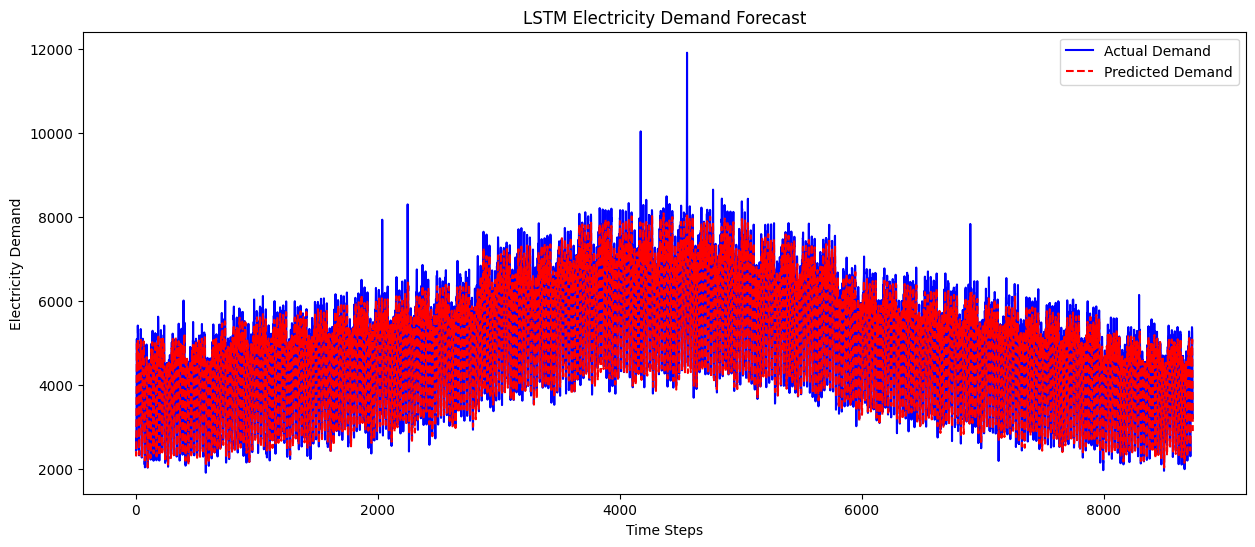

In [5]:
# Visualize the predictions vs actual values
plt.figure(figsize=(15,6))
plt.plot(range(len(Y_actual)), Y_actual, label='Actual Demand', color='blue')
plt.plot(range(len(predictions)), predictions, label='Predicted Demand', color='Red', linestyle='--')
plt.fill_between(range(len(predictions)), 
                 (predictions.flatten() - confidence_interval), 
                 (predictions.flatten() + confidence_interval), 
                 color='pink', alpha=0.5, label='95% Confidence Interval')
plt.title("LSTM Electricity Demand Forecast")
plt.xlabel("Time Steps")
plt.ylabel("Electricity Demand")
plt.legend()
plt.show()